In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import math
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [ ]:
# Mount Google Drive (if using Colab)
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Load the dataset
df1 = pd.read_csv('/content/drive/MyDrive/Dataset for google play store /googleplaystore.csv')
df2 = pd.read_csv('/content/drive/MyDrive/Dataset for google play store /googleplaystore_user_reviews.csv')

In [ ]:
# Inspect the dataset
print(df1.head())
print(df2.head())

                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free  0.00       Everyone   
1     967   14M     500,000+  Free  0.00       Everyone   
2   87510  8.7M   5,000,000+  Free  0.00       Everyone   
3  215644   25M  50,000,000+  Free  0.00           Teen   
4     967  2.8M     100,000+  Free  0.00       Everyone   

                      Genres      Last Updated  
0               Art & Design   January 7, 2018  
1  Art & Design;Pretend Play  January 15, 2018  
2               A

In [ ]:
# Preprocess 'Installs' column
def clean_installs(installs):
    if isinstance(installs, str):  # Check if it's a string
        installs = installs.replace(",", "")  # Remove commas
        if installs.endswith("+"):
            installs = installs[:-1]  # Remove '+'
        if installs == "Free":
            installs = 0.0  # Replace 'Free' with 0
    try:
        return float(installs)
    except ValueError:
        return np.nan  # Handle invalid values

df1['Installs'] = df1['Installs'].apply(clean_installs)


In [ ]:
# Clean 'Reviews' and 'Size' columns
df1['Reviews'] = pd.to_numeric(df1['Reviews'], errors='coerce')
df1['Size'] = df1['Size'].replace('Varies with device', np.nan)
df1['Size'] = df1['Size'].str.replace('M', '').str.replace('k', '')
df1['Size'] = pd.to_numeric(df1['Size'], errors='coerce')

In [ ]:
# Preprocess 'Price' column
def clean_price(price):
    if isinstance(price, str):  # Check if it's a string
        price = price.replace("$", "")  # Remove the dollar sign
    try:
        return float(price)  # Convert to float
    except ValueError:
        return np.nan  # Handle invalid values

df1['Price'] = df1['Price'].apply(clean_price)

In [ ]:
# Handle missing values for numerical columns (e.g., fill with mean)
numeric_cols = df1.select_dtypes(include=[np.number]).columns
df1[numeric_cols] = df1[numeric_cols].fillna(df1[numeric_cols].mean(), inplace=False)

In [ ]:
# Handle missing values for categorical columns (e.g., fill with 'Unknown')
categorical_cols = df1.select_dtypes(include=['object']).columns
df1[categorical_cols] = df1[categorical_cols].fillna('Unknown', inplace=False)

In [ ]:
# Plotting functions
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]]
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = math.ceil((nCol + nGraphPerRow - 1) / nGraphPerRow)
    plt.figure(figsize=(6 * nGraphPerRow, 8 * nGraphRow))
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            columnDf.value_counts().plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation=90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout()
    plt.show()

In [ ]:
def plotCorrelationMatrix(df, graphWidth):
    df = df.dropna(axis='columns')
    df = df.select_dtypes(include=[np.number])
    if df.shape[1] < 2:
        print('No correlation plots shown: Less than 2 columns')
        return
    corr = df.corr()
    plt.figure(figsize=(graphWidth, graphWidth))
    plt.matshow(corr, fignum=1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.colorbar()
    plt.show()

In [ ]:
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include=[np.number]).dropna(axis='columns')
    columnNames = list(df.columns)[:10]  # Reduce number of columns for matrix plot
    df_numerical = df[columnNames]
    ax = pd.plotting.scatter_matrix(df_numerical, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    plt.suptitle('Scatter and Density Plot')
    plt.show()


In [ ]:
# Categorize Apps Based on Predicted Installs
def categorize_app(installs):
    if installs >= 1000000:
        return 'Highly Popular'
    elif installs >= 50000 and installs<100000:
        return 'Popular'
    else:
        return 'Less Popular'

df1['Category_Predicted'] = df1['Installs'].apply(categorize_app)

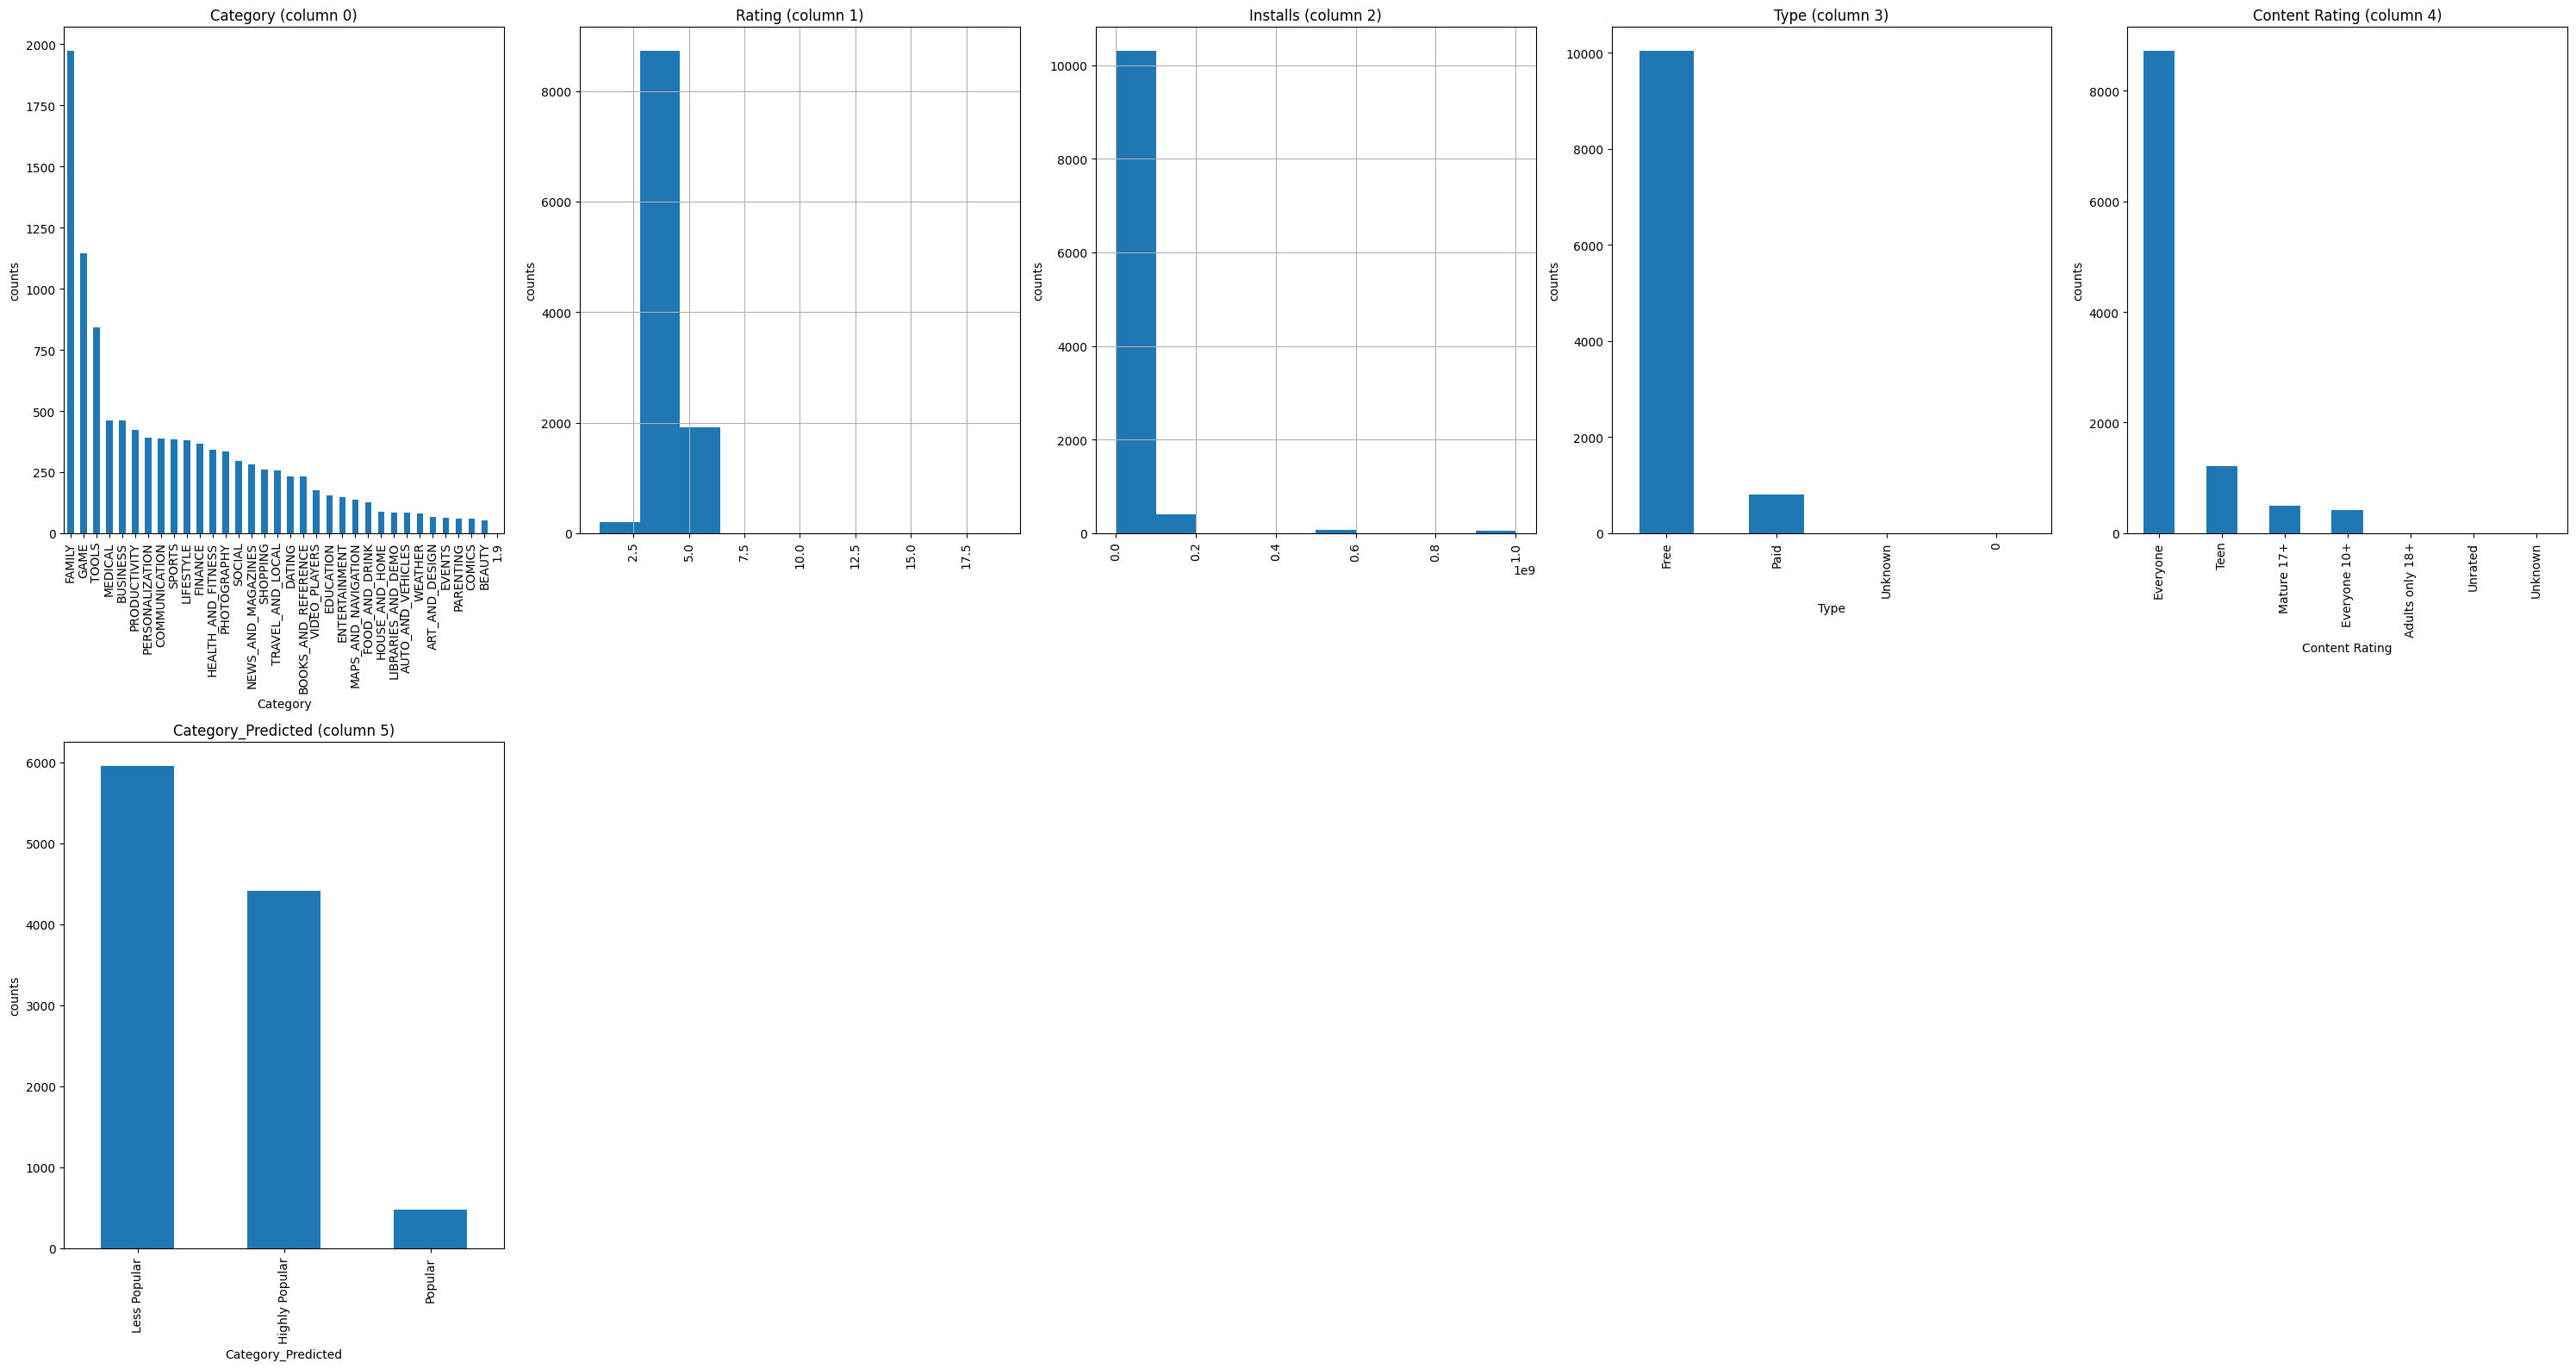

In [ ]:
# Visualizations
plotPerColumnDistribution(df1, 10, 5)

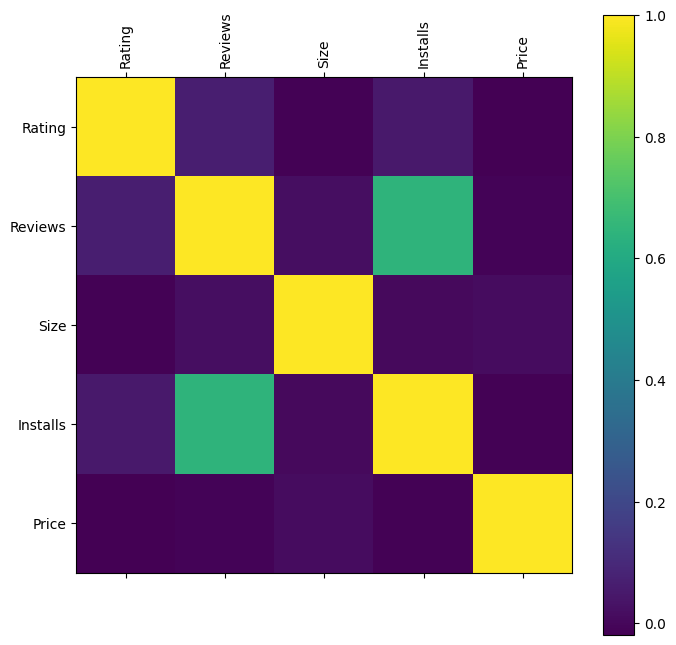

In [ ]:
plotCorrelationMatrix(df1, 8)

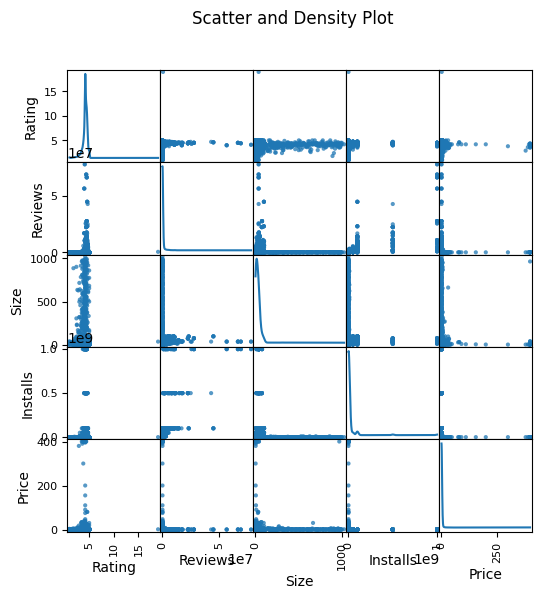

In [ ]:
plotScatterMatrix(df1, 6, 15)

In [ ]:
# Encode categorical features
le = LabelEncoder()
for col in ['App', 'Category', 'Content Rating', 'Genres', 'Last Updated', 'Type', 'Category_Predicted']:
    df1[col] = le.fit_transform(df1[col])
    print("Label Encoder classes: ", le.classes_)

Label Encoder classes:  ['"i DT" Fútbol. Todos Somos Técnicos.' '#NAME?'
 '+Download 4 Instagram Twitter' ...
 '💘 WhatsLov: Smileys of love, stickers and GIF'
 '📏 Smart Ruler ↔️ cm/inch measuring for homework!'
 '🔥 Football Wallpapers 4K | Full HD Backgrounds 😍']
Label Encoder classes:  ['1.9' 'ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FAMILY' 'FINANCE' 'FOOD_AND_DRINK' 'GAME' 'HEALTH_AND_FITNESS'
 'HOUSE_AND_HOME' 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'MAPS_AND_NAVIGATION'
 'MEDICAL' 'NEWS_AND_MAGAZINES' 'PARENTING' 'PERSONALIZATION'
 'PHOTOGRAPHY' 'PRODUCTIVITY' 'SHOPPING' 'SOCIAL' 'SPORTS' 'TOOLS'
 'TRAVEL_AND_LOCAL' 'VIDEO_PLAYERS' 'WEATHER']
Label Encoder classes:  ['Adults only 18+' 'Everyone' 'Everyone 10+' 'Mature 17+' 'Teen' 'Unknown'
 'Unrated']
Label Encoder classes:  ['Action' 'Action;Action & Adventure' 'Adventure'
 'Adventure;Action & Adventure' 'Adventure;Brain Games'

In [ ]:
# Feature Engineering - Select relevant features
features = ['Rating', 'Reviews', 'Installs', 'Price', 'Size', 'Category']
X = df1[features]

In [ ]:
# Define Target Variable (Assuming 'Category_Predicted' as a proxy for app success)
y = df1['Category_Predicted']

In [ ]:
# Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Train a Random Forest Regressor Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Get predictions for training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
# Training accuracy
training_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy:", training_accuracy)

Training Accuracy: 1.0


In [ ]:
# Testing accuracy
testing_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Testing Accuracy:", testing_accuracy)

Testing Accuracy: 1.0


In [ ]:
# Feature Importance Analysis
feature_importances = model.feature_importances_
print(f"Feature Importances: {feature_importances}")

Feature Importances: [0. 0. 1. 0. 0. 0.]


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Assuming ⁠ model ⁠ is your trained model and ⁠ category_encoder ⁠ is the encoder for 'Category'
# Assuming clean_installs and clean_price functions are defined elsewhere

# Initialize the LabelEncoder for 'Category' and fit it to the entire dataset categories
# Assuming df1 is your full dataset with the 'Category' column already populated
category_encoder = LabelEncoder()
df1['Category'] = category_encoder.fit_transform(df1['Category'])

# Define the prediction function
def predict_app_popularity(app_data):
    """Predicts the popularity category of an app using the trained model
       and the specified relevant features.
    """
    # Convert app data to DataFrame
    app_df = pd.DataFrame([app_data])

    # Preprocess features (similar to training data)
    app_df['Installs'] = clean_installs(app_df['Installs'])
    app_df['Reviews'] = pd.to_numeric(app_df['Reviews'], errors='coerce')
    app_df['Size'] = app_df['Size'].replace('Varies with device', np.nan)
    app_df['Size'] = app_df['Size'].astype(str).str.replace('M', '').str.replace('k', '')
    app_df['Size'] = pd.to_numeric(app_df['Size'], errors='coerce')
    app_df['Price'] = clean_price(app_df['Price'])

    # Impute missing values
    relevant_features = ['Rating', 'Reviews', 'Installs', 'Price', 'Size', 'Category']
    app_df[relevant_features] = app_df[relevant_features].fillna(df1[relevant_features].mean(), inplace=False)

    # Transform 'Category' feature using category_encoder
    try:
        app_df['Category'] = category_encoder.transform(app_df['Category'])
    except ValueError as e:
        unknown_category = str(e).split("'")[1]
        print(f"Warning: Unknown category '{unknown_category}'.")
        category_encoder.classes_ = np.append(category_encoder.classes_, unknown_category)
        app_df['Category'] = category_encoder.transform(app_df['Category'])

    # Make prediction
    X_app = app_df[relevant_features]
    prediction = model.predict(X_app)[0]

    # Interpret prediction
    return 'Highly Popular' if prediction == 2 else 'Popular' if prediction == 1 else 'Less Popular'

# Prompt user for input
user_data = {
    'Rating': float(input("Enter the app's rating (e.g., 4.5): ")),
    'Reviews': int(input("Enter the number of reviews (e.g., 10000): ")),
    'Installs': int(input("Enter the number of installs (e.g., 500000): ")),
    'Price': float(input("Enter the price (e.g., 0.0 for free apps): ")),
    'Size': float(input("Enter the size in MB (e.g., 25 for 25 MB): ")),
    'Category': input("Enter the app category (e.g., BUSINESS): ")
}

# Predict popularity category
predicted_category = predict_app_popularity(user_data)
print(f"Predicted Popularity Category: {predicted_category}")

Enter the app's rating (e.g., 4.5): 3.2
Enter the number of reviews (e.g., 10000): 100000
Enter the number of installs (e.g., 500000): 30000
Enter the price (e.g., 0.0 for free apps): 2.99
Enter the size in MB (e.g., 25 for 25 MB): 36
Enter the app category (e.g., BUSINESS): EDUCATION
Predicted Popularity Category: Popular


<ipython-input-7-3e96a1c3796d>:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(installs)
<ipython-input-9-3148d7844ebc>:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(price)  # Convert to float
